In [1]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

In [28]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *

import numpy as np
import matplotlib.pyplot as plt

In [29]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [30]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05

In [60]:
r_pupil = f * num_apt
r_bfp = L_bfp / 2
na_eff = num_apt
#effective NA can be limited by the size of the back focal plane
if r_bfp < r_pupil:
    na_eff = r_bfp / f
alpha = np.arcsin(na_eff / n)

theta_grid_size = 32
R_BFP = r_bfp

microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, theta_grid_size)

In [61]:
L_ffp = 0.0065
grid_ffp = 128

grid = Centered_Grid(L_ffp, grid_ffp, 0)
bead_img = Bead_Image(grid, [0], [0], [0.0005])

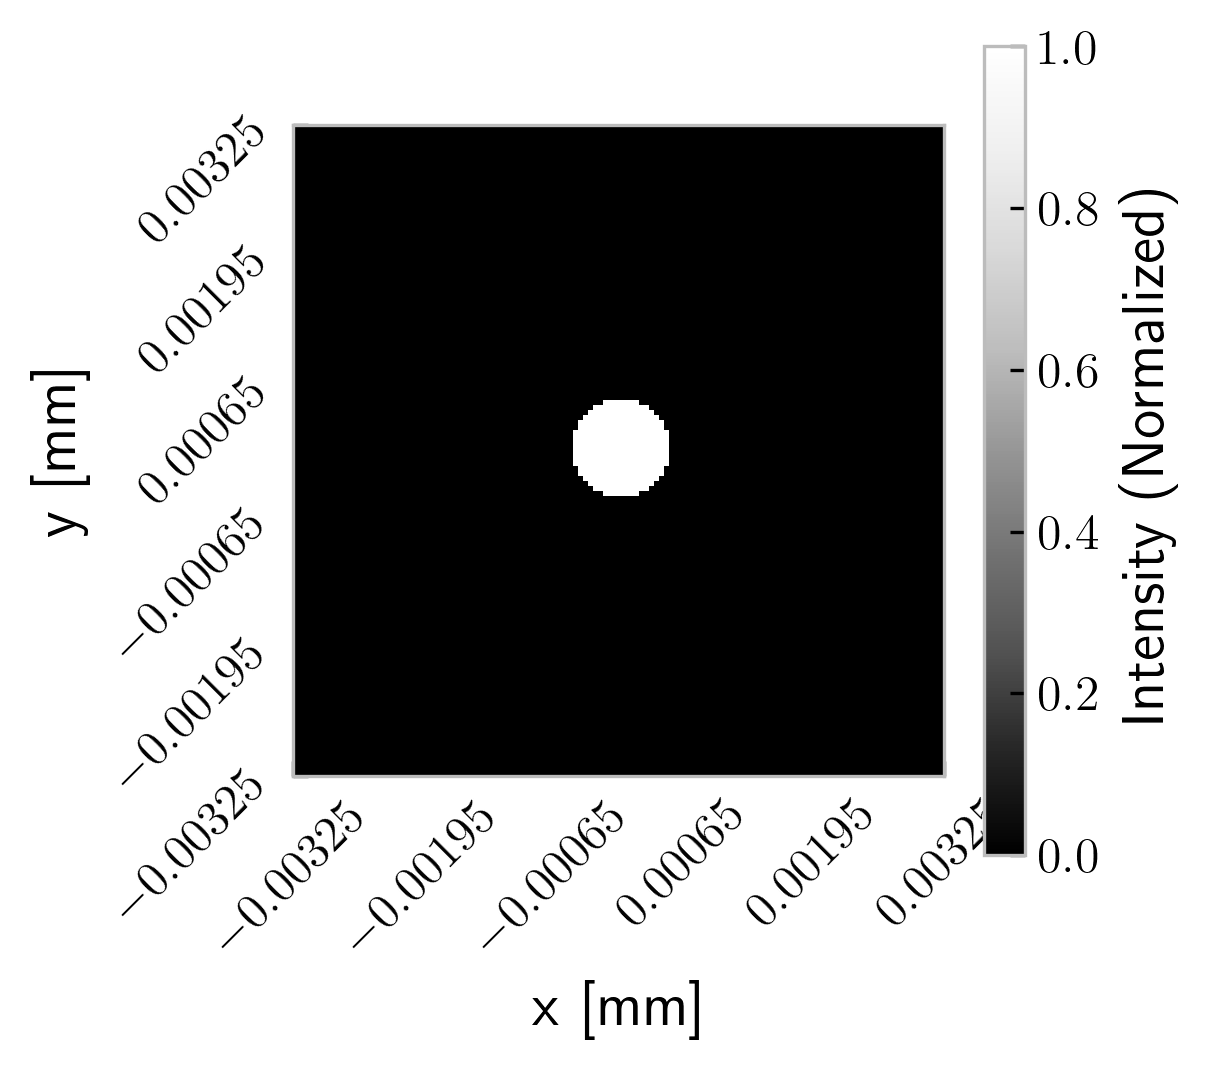

In [62]:
plot_intensity(*bead_img.get_xy(), bead_img.image_mask)

In [129]:
modes = [[0, 4], [-2, 2], [1, 3]]
strengths = [0.5, 0.3, 0.4]
innate_aberration = Aberration(modes, strengths)

In [130]:
slm = SLM(microscope, bead_img, innate_aberration)

Getting unaberrated quality...


In [131]:
correction_log, quality_log, bias_log, final_correction = slm.run_booth(5)

===== Running Booth 2002 Modal AO Algorithm =====
No specific modes inputted. Assuming all modes should be corrected.
Original Aberration:
n=0, m=4: 0.5
n=-2, m=2: 0.3
n=1, m=3: 0.4
===== Iteration 1=====
Getting raw image quality..
Image Quality: 0.213
Applying biases: 0.2 waves
	===Optimizing m=0, n=4===
	Exploring plus bias...
	Image Quality: 0.308
	Exploring minus bias...
	Image Quality: 0.468
	Evaluating next step...
	Computed step to be: -2589503485.743
		Rounding up to: -0.2 
	===Optimizing m=-2, n=2===
	Exploring plus bias...
	Image Quality: 0.244
	Exploring minus bias...
	Image Quality: 0.401
	Evaluating next step...
	Computed step to be: -2538152787.771
		Rounding up to: -0.2 
	===Optimizing m=1, n=3===
	Exploring plus bias...
	Image Quality: 0.308
	Exploring minus bias...
	Image Quality: 0.212
	Evaluating next step...
	Computed step to be: 1552202231.713
		Rounding down to: 0.2 
===== Iteration 2=====
Getting raw image quality..
Image Quality: 0.404
Applying biases: 0.16 wav

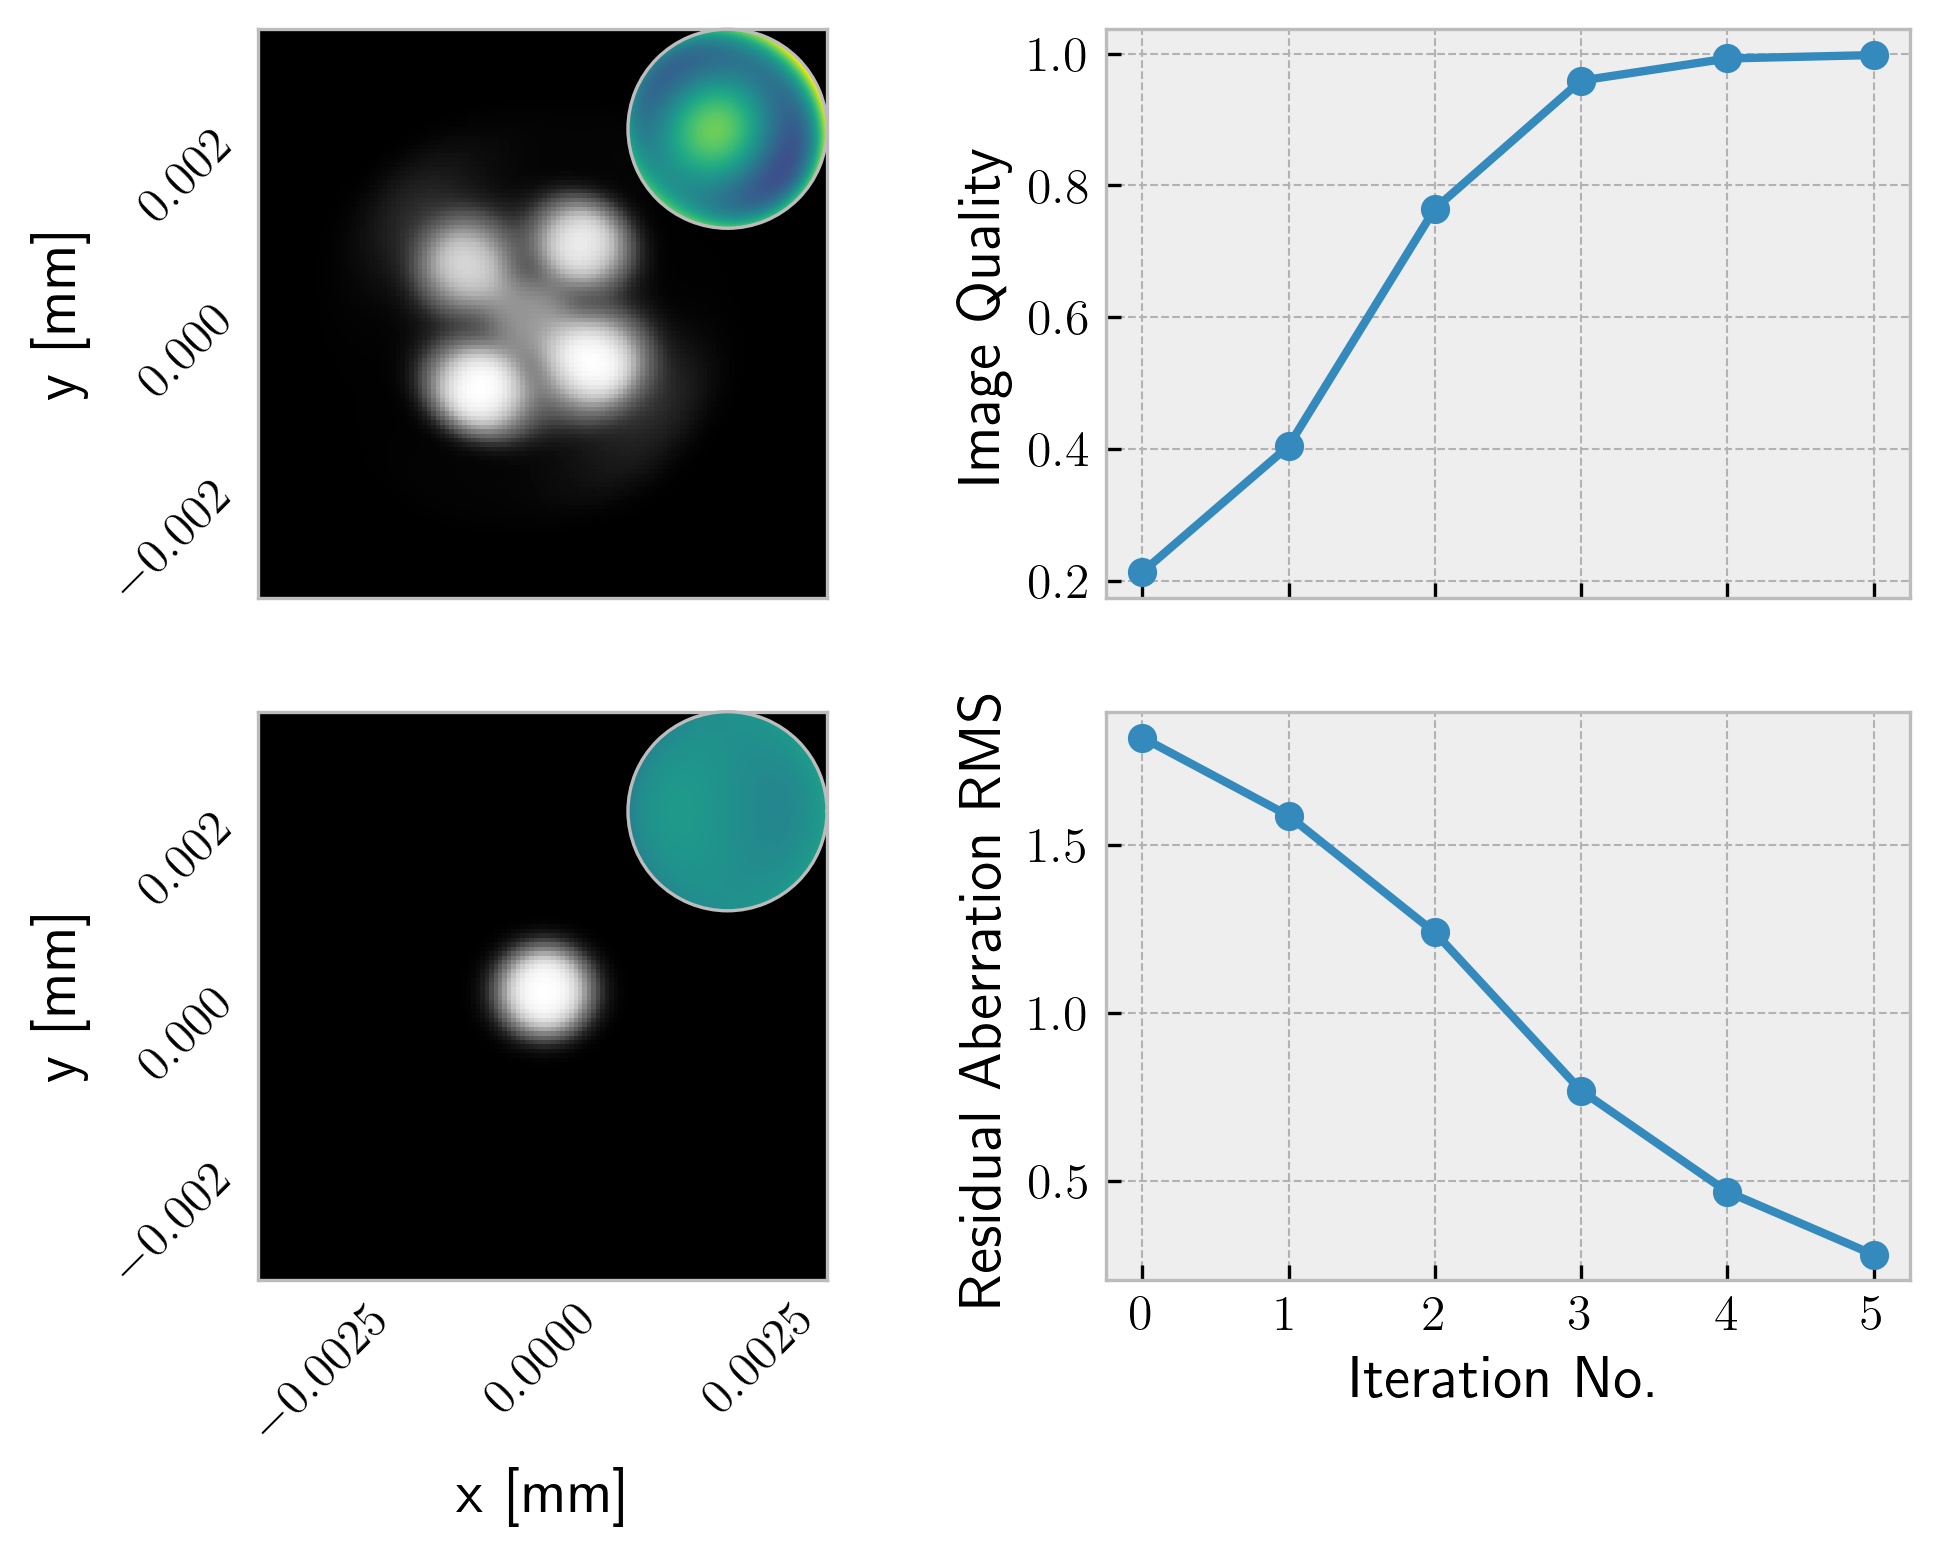

In [154]:
slm.produce_correction_graphic(quality_log, correction_log, final_correction)